# Otimização — Aulas assíncronas 2 e 3 

### Rosário D. Laureano


$\color{red}{\textbf{Contexto:}}$ O objetivo desta UC não é fazer cálculos "à mão", mas sim usar linguagem Python para obter os vários elementos necessários à otimização matemática, o que justifica este Jupyter notebook. Devem usar estes códigos para a resolução dos exercícios do ficheiro "Extremos livres - Otimização livre ou irrestrita" para exploração da otimização matemática.  

Como visto na 1ª aula síncrona, a otimização matemática requer muitos elementos de:
- $\textbf{álgebra linear}$, como multiplicação de matrizes, cálculo de determinantes e de valores próprios, forma quadrática associada a uma matriz, etc...
- $\textbf{cálculo diferencial}$ em $\mathbb{R}^n$, com $n\geq 1$, como derivada (total), derivadas parciais de diferentes ordens, vetor gradiente, matriz Hessiana, etc...

Neste Jupyter notebook encontra códigos para obtenção desses elementos mas, sempre que possível, é aqui dada uma versão longa que retrata a forma como obtínhamos estes elementos nas UC de matemática numa licenciatura.  
 

## 1. Multiplicação de matrizes ##

- definir as matrizes $A$ e $B$ 
- verificar se a multiplicação $A \times B$ é possível, ou seja, se há "compatibilidade" dos tipos/"dimensões" das matrizes $A$ e $B$: se o nº de colunas de $A$ igual ao nº de linhas de $B$
- calcular a matriz produto $A\times B$ (ou simplesmente $AB$), a qual terá o nº de linhas de $A$ e o nº de colunas de $B$.

### 1.1. Versão "longa" da multiplicação

Calcular passo-a-passo cada entrada/elemento da matriz produto:

In [1]:

# Definição da matriz A:

A = [
    [1, 2, -3],
    [4, -5, 6]
]


# Definição da matriz B:

B = [
    [7, 8, 1, 0],
    [9, 10, 5, 6],
    [11, -12, 3, 0]
]


# Visualização das matrizes:

from sympy import Matrix

from IPython.display import display

print("Matriz A:")
display(Matrix(A))

print("----------------------------------")

print("Matriz B:")
display(Matrix(B))

Matriz A:


Matrix([
[1,  2, -3],
[4, -5,  6]])

----------------------------------
Matriz B:


Matrix([
[ 7,   8, 1, 0],
[ 9,  10, 5, 6],
[11, -12, 3, 0]])

In [2]:

# Diferente visualização das matrizes:

print("Matriz A:")
for linha in A:
    print(linha)

print()

print("----------------------------------")

print("Matriz B:")
for linha in B:
    print(linha)

print()

Matriz A:
[1, 2, -3]
[4, -5, 6]

----------------------------------
Matriz B:
[7, 8, 1, 0]
[9, 10, 5, 6]
[11, -12, 3, 0]



In [3]:

# Obter o tipo/"dimensão" das matrizes:

linhas_A = len(A)    #Conta o nº de linhas da matriz A

colunas_A = len(A[0])    #Conta o nº de colunas da matriz A

linhas_B = len(B)  

colunas_B = len(B[0])  

print("Tipo da matriz A:")
print(linhas_A, "x", colunas_A)

print()

print("----------------------------------")

print("Tipo da matriz B:")
print(linhas_B, "x", colunas_B)

print()


Tipo da matriz A:
2 x 3

----------------------------------
Tipo da matriz B:
3 x 4



In [4]:

# Verificação da "compatibilidade" dos tipos/"dimensões" das matrizes fatores: 
#(número de colunas de A = número de linhas de B)

if colunas_A != linhas_B:

    print("Não está definida a multiplicação AxB.")

else:

    print("A multiplicação AxB está definida, ou seja, existe a matriz produto AxB.")
    print()



A multiplicação AxB está definida, ou seja, existe a matriz produto AxB.



NOTA: Em Python os índices começam em $0$ mas, no que segue, as linhas e as colunas estão enumeradas a partir de $1$, de modo a ficar mais próximo da notação matemática.

In [5]:

# Calcular a matriz produto AxB passo-a-passo (entrada a entrada):

C = []

for i in range(linhas_A):

    nova_linha = []

    for j in range(colunas_B):

        nova_linha.append(1)

    C.append(nova_linha)



# Fórmula de cálculo de cada entrada C_ij: C[i][j] = A[i][0]*B[0][j] + A[i][1]*B[1][j] + ...

for i in range(linhas_A):

   
    print("Linha", i+1, "da matriz resultado:")
    print("----------------------------------")
    print("----------------------------------")
    print()

    for j in range(colunas_B):

        print("Cálculo de C[", i+1, "][", j+1, "]")
        print()

        soma = 0

        for k in range(colunas_A):

            elemento_A = A[i][k]
            elemento_B = B[k][j]

            produto = elemento_A * elemento_B

            print(
                "A[", i+1, "][", k+1, "] =",
                elemento_A
            )

            print(
                "B[", k+1, "][", j+1, "] =",
                elemento_B
            )

            print(
                elemento_A,
                "*",
                elemento_B,
                "=",
                produto
            )

            soma = soma + produto

            print("Soma parcial =", soma)
            print()

        C[i][j] = soma

        print(
            "Valor final de C[",
            i+1,
            "][",
            j+1,
            "] =",
            soma
        )

        print()
        
        print("----------------------------------")
        print()


# Visualizar a matriz produto A*B: 

print("Matriz produto C=AxB:")

print()

for linha in C:
        print(linha)

Linha 1 da matriz resultado:
----------------------------------
----------------------------------

Cálculo de C[ 1 ][ 1 ]

A[ 1 ][ 1 ] = 1
B[ 1 ][ 1 ] = 7
1 * 7 = 7
Soma parcial = 7

A[ 1 ][ 2 ] = 2
B[ 2 ][ 1 ] = 9
2 * 9 = 18
Soma parcial = 25

A[ 1 ][ 3 ] = -3
B[ 3 ][ 1 ] = 11
-3 * 11 = -33
Soma parcial = -8

Valor final de C[ 1 ][ 1 ] = -8

----------------------------------

Cálculo de C[ 1 ][ 2 ]

A[ 1 ][ 1 ] = 1
B[ 1 ][ 2 ] = 8
1 * 8 = 8
Soma parcial = 8

A[ 1 ][ 2 ] = 2
B[ 2 ][ 2 ] = 10
2 * 10 = 20
Soma parcial = 28

A[ 1 ][ 3 ] = -3
B[ 3 ][ 2 ] = -12
-3 * -12 = 36
Soma parcial = 64

Valor final de C[ 1 ][ 2 ] = 64

----------------------------------

Cálculo de C[ 1 ][ 3 ]

A[ 1 ][ 1 ] = 1
B[ 1 ][ 3 ] = 1
1 * 1 = 1
Soma parcial = 1

A[ 1 ][ 2 ] = 2
B[ 2 ][ 3 ] = 5
2 * 5 = 10
Soma parcial = 11

A[ 1 ][ 3 ] = -3
B[ 3 ][ 3 ] = 3
-3 * 3 = -9
Soma parcial = 2

Valor final de C[ 1 ][ 3 ] = 2

----------------------------------

Cálculo de C[ 1 ][ 4 ]

A[ 1 ][ 1 ] = 1
B[ 1 ][ 4 ] = 0


### 1.2. Versão "curta" da multiplicação ###

Usar a biblioteca Numpy:

In [6]:
import numpy as np
from sympy import Matrix
from IPython.display import display

A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

B = np.array([
    [7, 8, 9, 10],
    [11, 12, 13, 14],
    [15, 16, 17, 18]
])

C = np.dot(A, B)

print("Matriz A:")
display(Matrix(A))

print("----------------------------------")

print("Matriz B:")
display(Matrix(B))

print("----------------------------------")

print("Matriz produto C = A x B:")
display(Matrix(C))

Matriz A:


Matrix([
[1, 2, 3],
[4, 5, 6]])

----------------------------------
Matriz B:


Matrix([
[ 7,  8,  9, 10],
[11, 12, 13, 14],
[15, 16, 17, 18]])

----------------------------------
Matriz produto C = A x B:


Matrix([
[ 74,  80,  86,  92],
[173, 188, 203, 218]])

## 2. Determinante de uma matriz (quadrada)

### 2.1. Matrizes de ordem $2$


Cálculo do determinante usando menores de ordem $2$ (ou tipo $2x2$), através da chamada $\textbf{Regra Cruzada}$:

In [7]:

# Calcular determinante de uma matriz de tipo 2x2 (ou de ordem 2):

A = [
    [3, 5],
    [2, 4]
]

print("Matriz A:")
for linha in A:
    print(linha)

print()

print("----------------------------------")

determinante = A[0][0] * A[1][1] - A[0][1] * A[1][0]

print("det(A) =", determinante)

Matriz A:
[3, 5]
[2, 4]

----------------------------------
det(A) = 2


### 2.2. Matrizes de ordem superior a $2$


Para matrizes $A$ de ordem superior a $2$, usamos o $\textbf{Teorema de Laplace}$ usando uma linha (ou uma coluna) para efetuar a expansão/desenvolvimento associada a essa linha (ou coluna). Esta expansão envolve determinantes de ordem imediatamente inferior, os chamados $\textbf{menores}$ da matriz $A$ para a linha (ou coluna) escolhida.

NOTA: Para matrizes $A$ de ordem $3$ é também conhecida a regra de Sarrus, mas consideramos mais útil relembrar o Teorema de Laplace. 

In [8]:

A = [
    [2, 1, 3],
    [0, 4, 5],
    [7, 2, 1]
]

print("Matriz A:")
for linha in A:
    print(linha)

print()

print("----------------------------------")

# Expandir/Desenvolver segundo Laplace através da 1ª linha da matriz A

# Menores associados à 1ª linha de A:


M11 = [
    [A[1][1], A[1][2]],
    [A[2][1], A[2][2]]    # Menor associado a a_11
]


M12 = [
    [A[1][0], A[1][2]],
    [A[2][0], A[2][2]]    # Menor associado a a_12
]


M13 = [
    [A[1][0], A[1][1]],
    [A[2][0], A[2][1]]    # Menor associado a a_13
]

print("Menor M11:")
for linha in M11:
    print(linha)

print()

print("Menor M12:")
for linha in M12:
    print(linha)

print()

print("Menor M13:")
for linha in M13:
    print(linha)

print()

print("----------------------------------")

# Calcular os determinantes dos menores, os quais são de ordem 2:


det_M11 = M11[0][0] * M11[1][1] - M11[0][1] * M11[1][0]
det_M12 = M12[0][0] * M12[1][1] - M12[0][1] * M12[1][0]
det_M13 = M13[0][0] * M13[1][1] - M13[0][1] * M13[1][0]

print("det(M11) =", det_M11)
print("det(M12) =", det_M12)
print("det(M13) =", det_M13)

print()


# Aplicar a expansão de Laplace: 


determinante = (
    A[0][0] * det_M11
    - A[0][1] * det_M12
    + A[0][2] * det_M13
)

print("----------------------------------")

print("det(A) =")
print(
    A[0][0], "*", det_M11,
    "-", A[0][1], "*", det_M12,
    "+", A[0][2], "*", det_M13
)

print()

print("det(A) =", determinante)

Matriz A:
[2, 1, 3]
[0, 4, 5]
[7, 2, 1]

----------------------------------
Menor M11:
[4, 5]
[2, 1]

Menor M12:
[0, 5]
[7, 1]

Menor M13:
[0, 4]
[7, 2]

----------------------------------
det(M11) = -6
det(M12) = -35
det(M13) = -28

----------------------------------
det(A) =
2 * -6 - 1 * -35 + 3 * -28

det(A) = -61



O determinante também pode ser efetuado de forma rápida usando a biblioteca Numpy:

In [9]:

# Calcular o determinante através da biblioteca Numpy: 

import numpy as np

A = np.array([
    [2, 1, 3],
    [0, 4, 5],
    [7, 2, 1]
])

determinante = np.linalg.det(A)

print(determinante)

-61.00000000000001


O resultado pode aparecer com casas decimais, mesmo quando o determinante é um número inteiro (como neste caso), devido às aproximações numéricas em vírgula flutuante. 

Podemos optar por exigir o valor inteiro (que neste caso é o valor exato do determinante): 

In [10]:

# Calcular o determinante através da biblioteca Numpy com valor inteiro:

import numpy as np

A = np.array([
    [2, 1, 3],
    [0, 4, 5],
    [7, 2, 1]
])

determinante = np.linalg.det(A)

print(round(determinante))

-61


Consideremos agora uma matriz de ordem $4$, e vejamos o cálculo através da Numpy:

In [11]:

# Calcular o determinante através da biblioteca Numpy:

import numpy as np

A = np.array([
    [2, 1, 3, 0],
    [0, 4, 5, 1.2],
    [7, 2, 1, 3],
    [1, -4, 2.3, 2]
])

determinante = np.linalg.det(A)

print(determinante)

-381.6799999999999


Podemos pedir mesmo um número concreto de casas decimais no arredondamento: 

In [12]:

# Calcular o determinante através da biblioteca Numpy com 1 casa decimal:

import numpy as np

A = np.array([
    [2, 1, 3, 0],
    [0, 4, 5, 1.2],
    [7, 2, 1, 3],
    [1, -4, 2.3, 2]
])

determinante = np.linalg.det(A)

print(round(determinante,1))

-381.7



Já agora, para a mesma matriz de ordem $4$, se apenas interessar o valor inteiro do determinante, fazemos:

In [13]:

# Calcular o determinante através da biblioteca Numpy de valor inteiro:

import numpy as np

A = np.array([
    [2, 1, 3, 0],
    [0, 4, 5, 1.2],
    [7, 2, 1, 3],
    [1, -4, 2.3, 2]
])

determinante = np.linalg.det(A)

print(round(determinante))

-382


onde vemos que arredondamento às unidades é automático.


A biblioteca Numpy não calcula os determinantes por expansão em menores, segundo o Teorema de Laplace. Usa a chamada $\textbf{decomposição ou fatorização LU}$ que, por sua vez, se baseia na conhecida $\textbf{eliminação de Gauss}$ (a fatorização LU dá suporte estrutural e teórico à eliminação de Gauss). A ideia é transformar a matriz $A$ em uma matriz triangular superior, ou seja, uma matriz com todas as entradas de valor $0$ abaixo da diagonal principal. Obtida a matriz triangular superior, o determinante é então igual ao produto dos elementos da diagonal principal, tendo atenção às trocas de linhas, porque cada troca muda o sinal do determinante (estas trocas de sinal estão "escondidas" numa das matrizes da fatorização LU).

Consideremos o código Python que mostra essa fatorização LU; temos assim, passo-a-passo, o que é executado com a biblioteca Numpy:

In [14]:

# Calcular o determinante usando fatorização LU: 

A = [
    [2, 1, 3],
    [0, 4, 5],
    [7, 2, 1]
]

print("Matriz A inicial:")
for linha in A:
    print(linha)

print()


M = []   # Podemos criar uma cópia da matriz A para não alterar a matriz original

for i in range(len(A)):
    nova_linha = []

    for j in range(len(A[i])):
        nova_linha.append(float(A[i][j]))

    M.append(nova_linha)

n = len(M)

numero_trocas = 0

print("----------------------------------")


# Efetuar a eliminação de Gauss:

# NOTA: se o pivô for 0, procuramos uma linha abaixo com entrada não nula na mesma coluna

for coluna in range(n): 

    if M[coluna][coluna] == 0:

        linha_para_trocar = -1

        for linha in range(coluna + 1, n):

            if M[linha][coluna] != 0:
                linha_para_trocar = linha

        if linha_para_trocar == -1:
            determinante = 0

        else:
            auxiliar = M[coluna]
            M[coluna] = M[linha_para_trocar]
            M[linha_para_trocar] = auxiliar

            numero_trocas = numero_trocas + 1

# e usamos o pivô para anular as entradas que estejam abaixo dele

    pivo = M[coluna][coluna]

    if pivo != 0:

        for linha in range(coluna + 1, n):

            fator = M[linha][coluna] / pivo

            for j in range(coluna, n):

                M[linha][j] = M[linha][j] - fator * M[coluna][j]

print("Matriz triangular superior obtida:")
for linha in M:
    print(linha)

print()

print("----------------------------------")


# Calcular o determinante usando as entradas da diagonal principal da matriz resultante

determinante = 1

for i in range(n):
    determinante = determinante * M[i][i]


if numero_trocas % 2 == 1:
    determinante = -determinante   # pois cada troca de linhas muda o sinal do determinante

print("Número de trocas de linhas:", numero_trocas)

print("Determinante:", determinante)

print("Determinante arredondado:", round(determinante))

Matriz A inicial:
[2, 1, 3]
[0, 4, 5]
[7, 2, 1]

----------------------------------
Matriz triangular superior obtida:
[2.0, 1.0, 3.0]
[0.0, 4.0, 5.0]
[0.0, 0.0, -7.625]

----------------------------------
Número de trocas de linhas: 0
Determinante: -61.0
Determinante arredondado: -61



A expansão por menores conforme o Teorema de Laplace cresce muito depressa, à medida que a ordem da matriz $A$ aumenta. Portanto, tornando-se impraticável para uma matriz $A$ de ordem $n$ grande: são muitos os determinantes de ordem mais baixa que vão surgindo, até chegar a determinantes de ordem $2$. Este crescimento rápido é do tipo fatorial.

Por sua vez, a fatorização LU tem um crescimento cúbico. Dado que exige a eliminação de Gauss até obter uma matriz triangular superior, são necessárias $n^3$ operações se a matriz $A$ for de ordem $n$.  

Fica justificada a escolha da fatorização LU (ou métodos relacionados), e não da expansão em menores conforme o Teorema de Laplace, na biblioteca Numpy. 

Eliminação de Gauss / LU: crescimento cúbico, cerca de n³ operações.
Por isso, para matrizes grandes, usa-se eliminação de Gauss, LU ou métodos relacionados.


### 2.3. Computação simbólica (Sympy) vs numérica (Numpy)


Com a Numpy, o resultado é numérico e pode ter pequenos erros de arredondamento em consequência das aproximações numéricas de vírgula flutuante. 

Podemos então usar a biblioteca Sympy, que permite obter o valor exato do determinante de uma matriz, pois esta biblioteca faz álgebra simbólica (não usa aproximações de vírgula flutuante como a biblioteca Numpy):

In [15]:

# Calcular o determinante através da biblioteca Sympy:

from sympy import Matrix
from IPython.display import display

A = Matrix([
    [2, 1, 3, 0],
    [0, 4, 5, 1.2],
    [7, 2, 1, 3],
    [1, -4, 2.3, 2]
])

print("Matriz A:")
display(A)

print("----------------------------------")

determinante = A.det()

print("Determinante exato:")
display(determinante)

Matriz A:


Matrix([
[2,  1,   3,   0],
[0,  4,   5, 1.2],
[7,  2,   1,   3],
[1, -4, 2.3,   2]])

----------------------------------
Determinante exato:


-381.680000000000


Note que o determinante desta matriz já está calculado acima usando Numpy, onde obtiovemos $-381.6799999999999$.

Podemos querer o determinante escrito na forma fracionária, de fração irredutível, bastando para isso que as entradas não inteiras da matriz $A$ sejam dadas nessa forma:

In [16]:

# Calcular o determinante através da Sympy, escrito como fração irredutível:

from sympy import Matrix
from sympy import Rational
from IPython.display import display

# Matriz com frações exatas

A = Matrix([
    [Rational(1, 2), 1],
    [1, Rational(1, 3)]
])

print("Matriz A:")
display(A)

print("----------------------------------")


print("Determinante:")

determinante = A.det()

display(determinante)

Matriz A:


Matrix([
[1/2,   1],
[  1, 1/3]])

----------------------------------
Determinante:


-5/6

## 3. Valores próprios de uma matriz (quadrada)

Usando a biblioteca Numpy:

In [17]:

# Calcular os valores próprios usando a biblioteca Numpy: 

import numpy as np


A = np.array([
    [4, 1],
    [2, 3]
])

print("Matriz A:")
print(A)


print("----------------------------------")


# eigvals = eigenvalues = valores próprios

valores_proprios = np.linalg.eigvals(A)

for i in range(len(valores_proprios)):

    print(
        "Valor próprio",
        i + 1,
        "=",
        valores_proprios[i]
    )

Matriz A:
[[4 1]
 [2 3]]
----------------------------------
Valor próprio 1 = 5.0
Valor próprio 2 = 2.0


Usando a biblioteca Sympy, com cálculo explícito do polinómio caraterístico (os valores próprios são as raízes desse polinómio): 

In [18]:

# Calcular os valores próprios com Sympy, explicitando o polinómio caraterístico: 

from sympy import Matrix
from sympy import symbols
from sympy import eye
from IPython.display import display


A = Matrix([
    [4, 1],
    [2, 3]
])


print("Matriz A:")
display(A)

print("----------------------------------")


I = eye(2)   #definir a matriz identidade (de ordem 2)

print("Matriz identidade:")
display(I)

print("----------------------------------")


lambda_simbolo = symbols('lambda')   #definir a variável mais usada para valor próprio

A_menos_lambda_I = A - lambda_simbolo * I    

print("Matriz A - λI:")
display(A_menos_lambda_I)

print("----------------------------------")


print("Polinómio característico:")

polinomio = A_menos_lambda_I.det()

display(polinomio)

print("----------------------------------")


print("Valores próprios:")

valores_proprios = A.eigenvals()  # eigenvals() devolve o valor próprio e a sua multiplicidade

for valor, multiplicidade in valores_proprios.items():

    print("Valor próprio =", valor)

    print("Multiplicidade algébrica =", multiplicidade)

Matriz A:


Matrix([
[4, 1],
[2, 3]])

----------------------------------
Matriz identidade:


Matrix([
[1, 0],
[0, 1]])

----------------------------------
Matriz A - λI:


Matrix([
[4 - lambda,          1],
[         2, 3 - lambda]])

----------------------------------
Polinómio característico:


lambda**2 - 7*lambda + 10

----------------------------------
Valores próprios:
Valor próprio = 5
Multiplicidade algébrica = 1
Valor próprio = 2
Multiplicidade algébrica = 1


Se não estamos interessados no polinómio caraterístico, basta:  

In [19]:

# Calcular os valores próprios usando a biblioteca Sympy:


A = Matrix([
    [4, 1],
    [2, 3]
])

print("Matriz A:")
display(A)

print("----------------------------------")


print("Valores próprios:")

valores_proprios = A.eigenvals()   # eigenvals() devolve o valor próprio e a sua multiplicidade


for valor, multiplicidade in valores_proprios.items():

    print("Valor próprio =", valor)

    print("Multiplicidade algébrica =", multiplicidade)

Matriz A:


Matrix([
[4, 1],
[2, 3]])

----------------------------------
Valores próprios:
Valor próprio = 5
Multiplicidade algébrica = 1
Valor próprio = 2
Multiplicidade algébrica = 1


## 4. Forma quadrática associada a uma matriz quadrada

### 4.1. Cálculo da expressão da forma quadrática

A toda a matriz quadrada podemos associar uma forma quadrática, seja qual for a ordem $n$ da matriz (com $n\geq 1$, sendo o caso $n=1$ pouco interessante).

In [20]:

# Calcular a expressão da forma quadrática associada a uma matriz de ordem 3:

from sympy import Matrix
from sympy import symbols
from IPython.display import display

A = Matrix([
    [2, 1, 3],
    [1, 4, 2],
    [3, 2, 5]
])

print("Matriz A:")
display(A)

print()

print("----------------------------------")


x1, x2, x3 = symbols('x1 x2 x3')    #definir as variáveis como símbolos

V = Matrix([    #definir a matriz coluna do vetor (x_1, x_2, x_3)
    [x1],
    [x2],
    [x3]
])

print("Matriz coluna V do vetor v:")
display(V)

print()

print("----------------------------------")


V_transposta = V.transpose()   #obter a matriz linha do vetor (x_1, x_2, x_3)

print("Matriz transposta de V:")
display(V_transposta)

print()

print("----------------------------------")


Q = V_transposta * A * V   #fórmula Q= V^TxAxV que define a forma quadrática


print("Expressão da forma quadrática:")

Q_escalar = Q[0]

display(Q_escalar)

Matriz A:


Matrix([
[2, 1, 3],
[1, 4, 2],
[3, 2, 5]])


----------------------------------
Matriz coluna V do vetor v:


Matrix([
[x1],
[x2],
[x3]])


----------------------------------
Matriz transposta de V:


Matrix([[x1, x2, x3]])


----------------------------------
Expressão da forma quadrática:


x1*(2*x1 + x2 + 3*x3) + x2*(x1 + 4*x2 + 2*x3) + x3*(3*x1 + 2*x2 + 5*x3)

### 4.2. Classificação da forma quadrática

Classificamos uma forma quadrática quando estudamos se ela é (i) definida positiva, (ii) semidefinida positiva, (iii) definida negativa, (iv) semidefinida negaitiva, ou (v) indefinida.

No contexto da otimização livre/irrestrita, vimos que a classificação de uma forma quadrática é essencial para classificar o(s) ponto(s) crítico(s)/estacionário(s) de uma certa função. 

Por sua vez, cada forma quadrática resulta de (multiplicações sobre) uma matriz; no contexto da otimização livre essa matriz é a matriz Hessiana. Assim, é natural que exista a possibilidade de classificar a forma quadrática diretamente através da sua matriz associada. Já agora, até é comum existir um certo abuso de linguagem: dizermos que o matriz é, por exemplo, definida positiva quando a sua forma quadrática é definida positiva (e o mesmo nos outros 4 tipos de classificação). A classificação da forma quadrática faz-se através da sua matriz associada usando:
- os valores próprios, ou
- os menores principais
  
dessa matriz associada.

#### 4.2.1 Classificação com base nos valores próprios da matriz associada

Uma das maneiras de classificar uma forma quadrática é através do sinal dos valores próprios da matriz real (matriz em que todas as entradas são números reais) que lhe está associada. Contudo, esses valores próprios podem ser números reais ou números complexos, sendo que estes últimos não têm sinal. 

Como contornar esta questão?


Um resultado fundamental da álgebra linear, o Teorema Espetral, estabelelce que se uma matriz real for simétrica, então todos os seus valores próprios são números reais. Já agora, este Teorema estabelece ainda que: 
- os vetores próprios associados a valores próprios diferentes são ortogonais;
- a matriz é diagonalizável;
- existe uma base ortonormada de vetores próprios.
São estas conclusões do Teorema Espetral que tornam as matrizes simétricas tão importantes em otimização e $\textit{machine learning}$. 

Ora, no contexto da otimização livre/irrestrita, classificamos a forma quadrática associada à matriz Hessiana da função objetivo (f.o.), e sabemos que esta matriz é simétrica (salvo casos muito excepcionais) em consequência do Teorema de Schwartz. 

Assim, foquemo-nos na classificação de formas quadráticas definidas por uma matriz simétrica, para garantir que todos os valores próprios são números reais e, assim, poder analisar os sinais desses valores próprios.

In [21]:

# Classificar uma forma quadrática através dos valores próprios da matriz simétrica associada:


from sympy import Matrix
from IPython.display import display

A = Matrix([
    [2, 1, 3],
    [1, 4, 2],
    [3, 2, 5]
])

print("Matriz A:")
display(A)

print("----------------------------------")


if A == A.transpose():
    print("A matriz A é simétrica.")   #para verificar se a matriz e simétrica
else:
    print("A matriz A não é simétrica.")

print()

print("----------------------------------")



valores_proprios = A.eigenvals()

lista_valores = []

print("Valores próprios de A:")

for valor, multiplicidade in valores_proprios.items():

    valor_aproximado = valor.evalf()   #para converter o valor próprio de simbólico para numérico

    print("Valor próprio =", valor_aproximado)
    print("Multiplicidade =", multiplicidade)
    print()

    for i in range(multiplicidade):
        lista_valores.append(valor_aproximado)

# Analisar o sinal dos valores próprios 

positivos = 0
negativos = 0
zeros = 0

tolerancia = 0.000001   

for valor in lista_valores:

    valor_complexo = complex(valor)   #Converter para número complexo, pois a SymPy pode usar expressões complexas intermédias

    parte_real = valor_complexo.real
    parte_imaginaria = valor_complexo.imag

#embora nos interesse classificar matrizes simétricas, salvaguardamos o caso de o não ser; neste caso, se a parte imaginária for muito pequena, tratamos o valor próprio como real

    if abs(parte_imaginaria) < tolerancia:

        valor_real = parte_real

        if valor_real > tolerancia:
            positivos = positivos + 1

        elif valor_real < -tolerancia:
            negativos = negativos + 1

        else:
            zeros = zeros + 1

    else:

        print("Apareceu um valor próprio com parte imaginária não desprezável:")
        print(valor_complexo)

print()

print("----------------------------------")


print("Número de valores próprios positivos =", positivos)
print("Número de valores próprios negativos =", negativos)
print("Número de valores próprios nulos =", zeros)

print()

print("----------------------------------")


# Indicar os critérios de classificação 

if positivos > 0 and negativos == 0 and zeros == 0:

    print("A forma quadrática é definida positiva.")

elif negativos > 0 and positivos == 0 and zeros == 0:

    print("A forma quadrática é definida negativa.")

elif positivos > 0 and negativos > 0:

    print("A forma quadrática é indefinida.")

elif zeros > 0 and negativos == 0:

    print("A forma quadrática é semidefinida positiva.")

elif zeros > 0 and positivos == 0:

    print("A forma quadrática é semidefinida negativa.")

else:

    print("Não foi possível classificar.")

Matriz A:


Matrix([
[2, 1, 3],
[1, 4, 2],
[3, 2, 5]])

----------------------------------
A matriz A é simétrica.

----------------------------------
Valores próprios de A:
Valor próprio = 8.07324653296653 - 0.e-20*I
Multiplicidade = 1

Valor próprio = 0.133010714417528 - 0.e-22*I
Multiplicidade = 1

Valor próprio = 2.79374275261595 + 0.e-20*I
Multiplicidade = 1


----------------------------------
Número de valores próprios positivos = 3
Número de valores próprios negativos = 0
Número de valores próprios nulos = 0

----------------------------------
A forma quadrática é definida positiva.



Este é um caso em que todos os valores próprios da matriz são números reais (claro, é uma matriz simétrica!), dados pelas aproximações: 
- $8.07324653296653>0$,
- $0.133010714417528>0$ e
- $2.79374275261595>0$.

São as raizes do polinómio caraterístico $p(\lambda)=\lambda ^3−11\lambda ^2+24\lambda−3$. 

#### 4.2.2 Classificação com base nos menores principais da matriz associada


É igualmente importante saber classificar a forma quadrática através dos menores principais da matriz que lhe está associada. Estes são: o determinante da matriz $M$ e os determinantes de menor ordem que resultam de eliminar as últimas linha e coluna, as duas últimas linhas e colunas, as três últimas linhas e colunas, e assim por diante. 

In [22]:

# Calcular os menores principais de uma matriz (quadrada):

from sympy import Matrix
from IPython.display import display


A = Matrix([
    [2, 1, 3],
    [1, 4, 2],
    [3, 2, 5]
])


print("Matriz A:")
display(A)

print()

print("----------------------------------")



M1 = A[:1, :1]       #obter a submatriz principal de ordem 1

print("Submatriz principal de ordem 1:")       #exibir a submatriz principal de ordem 1
display(M1)

det_M1 = M1.det()       #obter o menor principal de ordem 1

print("Menor principal de ordem 1:")        #exibir o valor do menor principal de ordem 1
display(det_M1)

print()

print("----------------------------------")



M2 = A[:2, :2]      #obter a submatriz principal de ordem 2

print("Submatriz principal de ordem 2:")       #exibir a submatriz principal de ordem 2
display(M2)

det_M2 = M2.det()        #obter o menor principal de ordem 2

print("Menor principal de ordem 2:")       #exibir o valor do menor principal de ordem 2
display(det_M2)

print()

print("----------------------------------")



M3 = A         #obter a "submatriz" principal de ordem 3, a própria matriz

print("Submatriz principal de ordem 3:")        #exibir a "submatriz" principal de ordem 2
display(M3)

det_M3 = M3.det()        #obter o menor principal de ordem 3

print("Menor principal de ordem 3:")        #exibir o valor do menor principal de ordem 3
display(det_M3)

print()

print("----------------------------------")


print("Menores principais:")     #exibir todos os menores principal da matriz

print("Δ1 =", det_M1)
print("Δ2 =", det_M2)
print("Δ3 =", det_M3)

Matriz A:


Matrix([
[2, 1, 3],
[1, 4, 2],
[3, 2, 5]])


----------------------------------
Submatriz principal de ordem 1:


Matrix([[2]])

Menor principal de ordem 1:


...


----------------------------------
Submatriz principal de ordem 3:


Matrix([
[2, 1, 3],
[1, 4, 2],
[3, 2, 5]])

Menor principal de ordem 3:


3


----------------------------------
Menores principais:
Δ1 = 2
Δ2 = 7
Δ3 = 3



## 5. Estudo simbólico de pontos críticos

### 5.1 Derivada total de 1ª ordem


Para uma função $f$ com uma só variável, é possivel obter a expressão geral das derivadas usando a biblioteca Sympy para cálculo simbólico.

In [23]:

# Calcular a derivada (total) de 1ª ordem de uma função uni-variável:

from sympy import symbols
from sympy import diff
from IPython.display import display

x = symbols('x')   #definir a variável

f = x**3 + 2*x**2 - 5*x + 1   #definir a função f(x) = x^3 + 2x^2 - 5x + 1 

print("Expressão da função f:")   #exibir a função f
display(f)

print()

print("----------------------------------")

f_derivada = diff(f, x)   #calcular a 1ª derivada usando diff(função, variável)

print("Expressão da função f':")   #exibir a função f'
display(f_derivada)

Expressão da função f:


x**3 + 2*x**2 - 5*x + 1


----------------------------------
Expressão da função f':


3*x**2 + 4*x - 5

### 5.2 Derivadas parciais de 1ª ordem




Para uma função $f$ com mais do que uma variável, há que definir a variável em cada pedido da expressão de uma derivada parcial.

In [24]:


# Calcular as derivadas parciais de 1ª ordem de uma uma função com 2 variáveis: 

from sympy import symbols
from sympy import diff
from IPython.display import display

x, y = symbols('x y')   #definir as variáveis


f = x**2 * y + 3*x * y**2 - y**3     #definir a função f(x,y) = x^2*y + 3*x*y^2 - y^3

print("Função f(x,y):")   #exibir a expressão que define a função
display(f)

print()

print("----------------------------------") 


f_x = diff(f, x)   #obter a derivada parcial em ordem a x usando diff(função, variável)

print("Expressão da derivada parcial de 1ª ordem na variável x:")    
display(f_x)

print()

print("----------------------------------") 


f_y = diff(f, y)  #obter a derivada parcial em ordem a x usando diff(função, variável)

print("Expressão da derivada parcial de 1ª ordem na variável y:")
display(f_y)

print()

Função f(x,y):


x**2*y + 3*x*y**2 - y**3


----------------------------------
Expressão da derivada parcial de 1ª ordem na variável x:


2*x*y + 3*y**2


----------------------------------
Expressão da derivada parcial de 1ª ordem na variável y:


x**2 + 6*x*y - 3*y**2


Em otimização sabemos que é especialmente importante o vetor das derivadas parciais de 1ª ordem - o vetor gradiente -, já que indica a direcção e sentido de maior crescimento/aumento da função. Ele pode ser obtido após o cálculo das derivadas parciais de 1ª ordem: 

In [25]:

# Calcular o vetor gradiente de uma função:

from sympy import symbols
from sympy import Matrix
from IPython.display import display

x, y = symbols('x y')

f = x**2 * y + 3*x * y**2 - y**3


print("Função f(x,y):")
display(f)

print()

print("----------------------------------") 


gradiente = Matrix([   #obter o vetor das derivadas parciais de 1ª ordem, ou seja, o vetor gradiente da função, na forma de matriz coluna
    [f.diff(x)],        
    [f.diff(y)]
])

print("Vetor gradiente:")   #exibir o vetor gradiente
display(gradiente)

Função f(x,y):


x**2*y + 3*x*y**2 - y**3


----------------------------------
Vetor gradiente:


Matrix([
[       2*x*y + 3*y**2],
[x**2 + 6*x*y - 3*y**2]])

In [26]:

# Calcular o gradiente de uma função multi-variável

from sympy import symbols
from sympy import derive_by_array
from IPython.display import display

x, y = symbols('x y')

f = x**2 * y + 3*x * y**2 - y**3

print("Função f(x,y):")
display(f)

print()

print("----------------------------------") 


gradiente = derive_by_array(f, (x, y))   #obter o vetor gradiente da função na forma de matriz linha


print("Matriz linha do vetor gradiente de f:")   #exibir o vetor gradiente 
display(gradiente)


Função f(x,y):


x**2*y + 3*x*y**2 - y**3


----------------------------------
Matriz linha do vetor gradiente de f:


[2*x*y + 3*y**2, x**2 + 6*x*y - 3*y**2]

## 5.3 Sistema de estacionaridade 


O sistema de anulação de todas as derivadas parciais de 1ª ordem - o sistema de estacionaridade -, fornece os pontos críticos/estacionários de uma função $f$ com mais do que uma variável (função multi-variável). Este sistema corresponde a considerar que o vetor gradiente de $f$ é o vetor nulo. No caso de termos uma função $f$ com uma só variável $x$, não temos um sistema mas sim uma única equação: $f'(x)=0$. 

In [27]:

# Resolver o sistema de estacionaridade  ∇f(x,y) = 0

from sympy import symbols
from sympy import Matrix
from sympy import solve
from IPython.display import display

x, y = symbols('x y')


f = x**2 * y + 3*x * y**2 - y**3

print("Função f(x,y):")
display(f)

print()

print("----------------------------------") 

gradiente = Matrix([      #calcular o vetor gradiente na forma de matriz coluna
    [f.diff(x)],
    [f.diff(y)]
])

print("Vetor gradiente de f:")     #exibir o gradiente
display(gradiente)

print()

print("----------------------------------") 

equacao_1 = f.diff(x)    #definir as equações do sistema de estacionaridade
equacao_2 = f.diff(y)


solucoes = solve(             #resolver o sistema de estacionaridade
    [equacao_1, equacao_2],
    [x, y],
    dict=True
)

print("Ponto(s) crítico(s)/estacionário(s) de f:")

for solucao in solucoes:     #exibir as soluções 
  
    ponto_x = solucao[x]
    ponto_y = solucao[y]
    
    display((ponto_x, ponto_y))

Função f(x,y):


x**2*y + 3*x*y**2 - y**3


----------------------------------
Vetor gradiente de f:


Matrix([
[       2*x*y + 3*y**2],
[x**2 + 6*x*y - 3*y**2]])


----------------------------------
Ponto(s) crítico(s)/estacionário(s) de f:


(0, 0)

### 5.4 Matriz Hessiana 

Usamos a matriz Hessiana de uma função $f$, constituída por todas as derivadas parciais de 2ª ordem de $f$, para a classificação do(s) ponto(s) crítico(s) de $f$, anteriormente obtidos pelo sistema de estacionaridade (são as soluções deste sistema). Nem sempre esta matriz permite concluir se um ponto crítico de $f$ é ou não extremo (maximizante ou minimizante) e se é um ponto de sela, podendo ser necessário recorrer a derivadas de ordem superior a $2$ (que está fora do âmbito desta UC) ou a uma "manipulação" adequada da própria expressão que define $f$. No entanto, é por esta matriz que iniciamos a classificação do(s) ponto(s) crítico(s).

In [28]:

# Calcular a expressão geral da matriz Hessiana de uma função f(x,y):

from sympy import symbols
from sympy import hessian
from IPython.display import display

x, y = symbols('x y')

f = x**2 * y + 3*x * y**2 - y**3


print("Função f(x,y):")
display(f)

print()

print("----------------------------------") 


H = hessian(f, (x, y))  #obter a matriz Hessiana

print("Matriz Hessiana de f:")   #exibir a matriz Hessiana
display(H)

Função f(x,y):


x**2*y + 3*x*y**2 - y**3


----------------------------------
Matriz Hessiana de f:


Matrix([
[      2*y, 2*x + 6*y],
[2*x + 6*y, 6*x - 6*y]])

### 6. Representações gráficas 

Tem particular interesse saber o vetor gradiente em cada ponto é perpendicular à curva de nível que passa nesse ponto:

Função f:


4*x**2 + 9*y**2

----------------------------------
Expressão da derivada parcial de 1ª ordem de f na variável x:


8*x

Expressão da derivada parcial de 1ª ordem de f na variável y:


18*y

----------------------------------


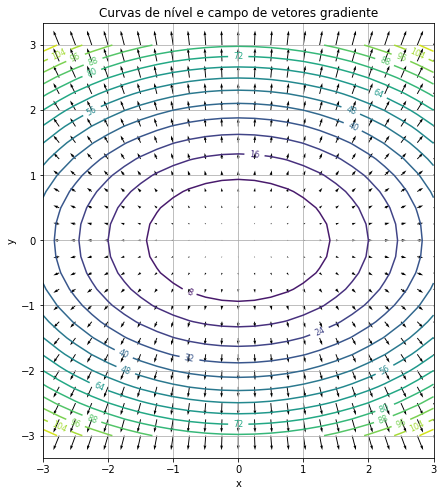

In [29]:

#Representar as curvas de nível e o campo de vetores gradiente de uma função f: 

import numpy as np
import matplotlib.pyplot as plt

from sympy import symbols
from sympy import diff
from sympy import lambdify
from IPython.display import display


x, y = symbols('x y')


f = 4*x**2 + 9*y**2     #define a função f(x,y) = 4x^2 + 9y^2

print("Função f:")
display(f)

print("----------------------------------") 

f_x = diff(f, x)        #calcula as derivadas parciais de 1ª ordem de f
f_y = diff(f, y)


print("Expressão da derivada parcial de 1ª ordem de f na variável x:")
display(f_x)


print("Expressão da derivada parcial de 1ª ordem de f na variável y:")
display(f_y)

print("----------------------------------") 


funcao_numerica = lambdify((x, y), f, "numpy")           #converte cada expressão simbólica em função numérica, pois o matplotlib trabalha com valores numéricos
gradiente_x_numerico = lambdify((x, y), f_x, "numpy")
gradiente_y_numerico = lambdify((x, y), f_y, "numpy")


valores_x = np.linspace(-3, 3, 25)     #cria a grelha de pontos (x,y)
valores_y = np.linspace(-3, 3, 25)

X, Y = np.meshgrid(valores_x, valores_y)    


Z = funcao_numerica(X, Y)    #calcula os valores da função f e das suas derivadas parciais de 1ª ordem nos pontos (X,Y) da grelha

U = gradiente_x_numerico(X, Y)
V = gradiente_y_numerico(X, Y)

plt.figure(figsize=(7, 8))    #estabelece as dimensões da representação/figura


curvas = plt.contour(X, Y, Z, levels=15)    #define as curvas de nível de f para 15 valores de Z

plt.clabel(curvas, inline=True, fontsize=8)    #exibe a curvas de nível de f


plt.quiver(X, Y, U, V)     #representa o campo de vetores gradiente: em cada ponto (X,Y) é aplicado/nasce o vetor (U,V)


plt.title("Curvas de nível e campo de vetores gradiente")   #estabelece os elementos gráficos da representação/figura
plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)
plt.axis("equal")

plt.show()    #exibe a representação/figura

Vejamos como obter a superfície do gráfico de uma função $f$ com $2$ variáveis: 

Função f(x,y):


4*x**2 + 9*y**2

----------------------------------


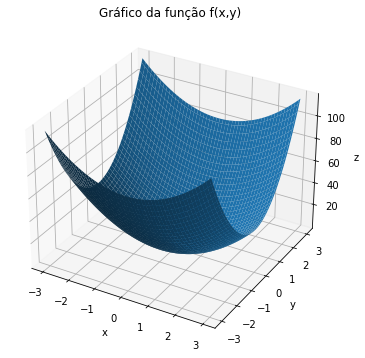

In [30]:

# Representar a superfície z = f(x,y) do gráfico de uma função f com 2 variáveis:

import numpy as np
import matplotlib.pyplot as plt

from sympy import symbols
from sympy import lambdify
from IPython.display import display

x, y = symbols('x y')

f = 4*x**2 + 9*y**2     #define a função f(x,y) = 4x^2 + 9y^2

print("Função f(x,y):")
display(f)

print("----------------------------------") 


f_numerica = lambdify((x, y), f, "numpy")   #converte cada expressão simbólica em função numérica, pois o matplotlib trabalha com valores numéricos


valores_x = np.linspace(-3, 3, 100)

valores_y = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(valores_x, valores_y)


Z = f_numerica(X, Y)       #calcula os valores de Z=f(X,Y)


figura = plt.figure(figsize=(8, 6))           #cria a figura/representação tridimensional

grafico = figura.add_subplot(111, projection='3d')    

grafico.plot_surface(X, Y, Z)


grafico.set_title("Gráfico da função f(x,y)")   #estabelece os elementos gráficos da figura/representação

grafico.set_xlabel("x")

grafico.set_ylabel("y")

grafico.set_zlabel("z")

plt.show()

Para uma função com $3$ variáveis, $w=f(x,y,z)$, as superfícies de nível são muito úteis, à falta do gráfico da função. Temos exemplo de uma superfície de nível $k=9$ e sobre ela são desenhados $6$ vetores gradiente de $f$:  

Função f:


x**2 + y**2 + z**2

----------------------------------


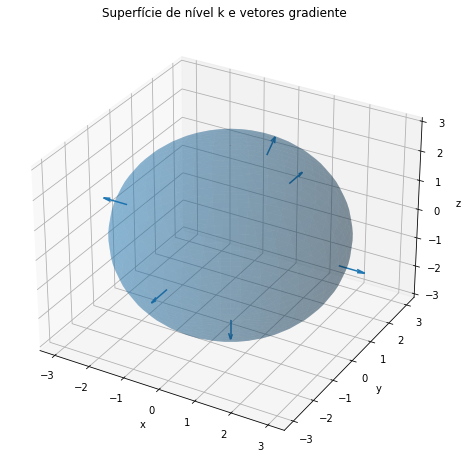

In [31]:

# Representar uma superfície de nível k para uma função de 3 variáveis e alguns vetores gradientes nessa superfície:

import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols
from IPython.display import display

x, y, z = symbols('x y z')


f = x**2 + y**2 + z**2

print("Função f:")
display(f)

print("----------------------------------") 



r = 3        #define a superfície de nível, para k=9, a qual é a superfície esférica x^2+y^2+z^2=9


u = np.linspace(0, 2*np.pi, 40)      #parametriza a superfície esférica x^2+y^2+z^2=9

v = np.linspace(0, np.pi, 40)

X = r * np.outer(np.cos(u), np.sin(v))

Y = r * np.outer(np.sin(u), np.sin(v))

Z = r * np.outer(np.ones(np.size(u)), np.cos(v))



fig = plt.figure(figsize=(10,8))        #cria a figura/representação

ax = fig.add_subplot(111, projection='3d')     



ax.plot_surface(X, Y, Z, alpha=0.3)     #representa a superfície de nível k=9



x_pontos = np.array([3, -3, 0, 0, 1, 0])     #escolhe 6 pontos sobre a superfície de nível onde são aplicados/nascem os vetores gradiente 

y_pontos = np.array([0, 0, 3, -3, 0, 0])

z_pontos = np.array([0, 0, 0, 0, 3, -3])



U = 2 * x_pontos     #define a expressão geral de cada coordenada de vetor gradiente, ∇f = (2x, 2y, 2z) 

V = 2 * y_pontos

W = 2 * z_pontos


ax.quiver(        #representa os 6 vetores gradiente
    x_pontos,
    y_pontos,
    z_pontos,
    U,
    V,
    W,
    length=0.7,
    normalize=True
)


ax.set_title("Superfície de nível k e vetores gradiente")      #estabelece os elementos gráficos da figura/representação

ax.set_xlabel("x")

ax.set_ylabel("y")

ax.set_zlabel("z")

plt.show()

Neste caso cada superfície de nível é uma superfície esferica, logo fácil de parametrizar. Quando tal não é fácil, podemos recorrer à marcação de pontos (em número elevado, claro!):

Função f:


6*x**2 - y**2 + 9*z**2


----------------------------------
Nível k = 10

----------------------------------


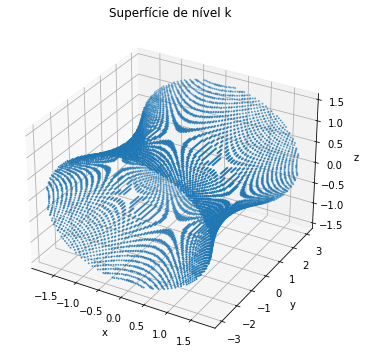

In [32]:

# Representar uma superfície de nível de uma função de 3 variáveis:

import numpy as np
import matplotlib.pyplot as plt

from sympy import symbols
from sympy import lambdify
from IPython.display import display


x, y, z = symbols('x y z')


f = 6*x**2 - y**2 +9*z**2

print("Função f:")
display(f)

print()

print("----------------------------------") 


k = 10

print("Nível k =", k)

print()

print("----------------------------------") 


f_numerica = lambdify((x, y, z), f, "numpy")      #define a expressão simbólica como função numérica



valores = np.linspace(-3, 3, 150)       #define a grelha de pontos

X, Y, Z = np.meshgrid(valores, valores, valores)


F = f_numerica(X, Y, Z)     #calcula os valores da função

tolerancia = 0.15     

indices = np.abs(F - k) < tolerancia



fig = plt.figure(figsize=(8,6))        #cria a figura/representação

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X[indices],
    Y[indices],
    Z[indices],
    s=1
)


ax.set_title("Superfície de nível k")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()